# Gaussian-Group Label Coherence

Quick visualization for MFA components clustered by Bhattacharyya distance, then scored by within-group label-description cosine similarity.

The default path points at the completed layer 17, K=1000, q=10 run. Change `RUN_DIR` to inspect q=337 once its outputs exist.

In [ ]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RUN_DIR = REPO / "output/experiments/1000_17_q337"

coherence_path = RUN_DIR / "gaussian_group_label_coherence.json"
members_path = RUN_DIR / "gaussian_group_members.csv"
labels_path = RUN_DIR / "cluster_labels/cluster_labels.json"

assert coherence_path.exists(), coherence_path
assert members_path.exists(), members_path

coherence = json.loads(coherence_path.read_text())
members = pd.read_csv(members_path)
groups = pd.DataFrame([
    {
        "group_id": g["group_id"],
        "size": g["size"],
        "label_cosine_mean": g["label_cosine"]["mean"],
        "label_cosine_median": g["label_cosine"]["median"],
        "label_cosine_min": g["label_cosine"]["min"],
        "label_cosine_max": g["label_cosine"]["max"],
        "distance_mean": g["distance"]["mean"],
        "distance_median": g["distance"]["median"],
        "distance_min": g["distance"]["min"],
        "distance_max": g["distance"]["max"],
        "component_ids": g["component_ids"],
    }
    for g in coherence["groups"]
])

coherence["metadata"], coherence["summary"]

({'labels_path': 'output/experiments/1000_17_q10/cluster_labels/cluster_labels.json',
  'gaussian_overlap_path': 'output/experiments/1000_17_q10/gaussian_overlap.pt',
  'distance_key': 'db',
  'distance_threshold': 25.8,
  'linkage': 'average',
  'top_groups': 10,
  'model_name': 'sentence-transformers/all-MiniLM-L6-v2'},
 {'n_components': 1000,
  'n_gaussian_groups': 889,
  'n_non_singleton_gaussian_groups': 93,
  'largest_group_sizes': [4, 4, 4, 3, 3, 3, 3, 3, 3, 3],
  'n_selected_groups': 10})

In [2]:
groups

,group_id,size,label_cosine_mean,label_cosine_median,label_cosine_min,label_cosine_max,distance_mean,distance_median,distance_min,distance_max,component_ids
0,0,4,0.677141,0.400699,0.371220,0.988041,23.615488,20.026852,18.948120,38.162834,"[103, 363, 415, 899]"
1,1,4,0.623396,0.607684,0.553761,0.721740,21.295959,18.643299,16.111862,26.245476,"[257, 292, 395, 965]"
2,2,4,0.824512,0.732288,0.712694,0.952052,19.667679,19.384434,17.176876,22.411278,"[285, 620, 744, 815]"
3,3,3,0.594073,0.578492,0.550964,0.652762,21.826468,20.885723,17.303608,27.290066,"[14, 353, 785]"
4,4,3,0.327963,0.111587,0.094006,0.778297,24.130188,23.052441,22.073120,27.264999,"[17, 84, 202]"
5,5,3,0.623945,0.633750,0.571966,0.666119,22.151236,22.153374,18.924084,25.376251,"[21, 301, 939]"
6,6,3,0.696307,0.684468,0.682205,0.722247,21.677254,22.101913,19.635372,23.294476,"[41, 393, 916]"
7,7,3,0.744045,0.755059,0.611224,0.865852,23.909616,22.978283,21.943909,26.806656,"[63, 679, 988]"
8,8,3,0.750858,0.732517,0.725651,0.794406,23.555298,24.595474,21.226955,24.843468,"[98, 711, 986]"
9,9,3,0.614799,0.580627,0.423921,0.839850,19.905823,18.604843,17.481552,23.631073,"[143, 742, 884]"


## Largest Gaussian-Groups

Bars show group population and within-group label cosine. The error bars span min to max cosine among label pairs inside the Gaussian-group.

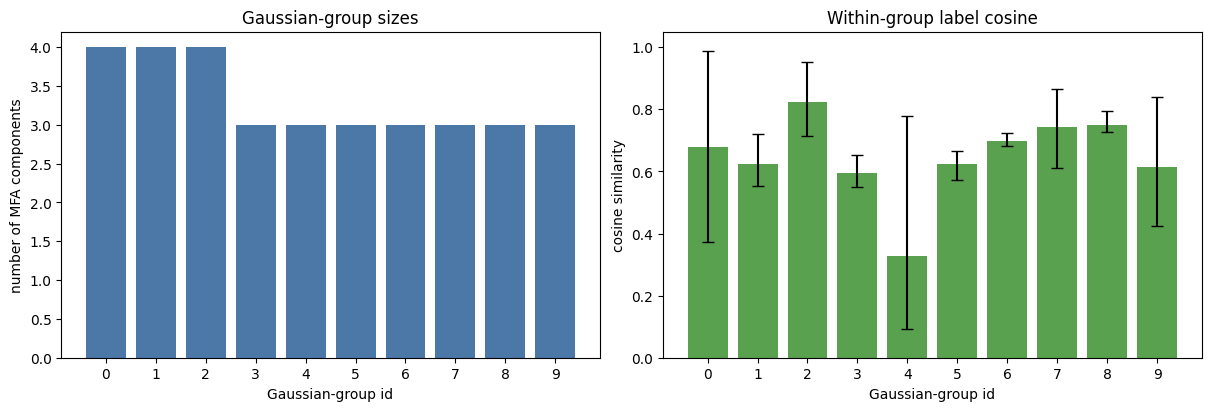

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].bar(groups["group_id"].astype(str), groups["size"], color="#4C78A8")
axes[0].set_title("Gaussian-group sizes")
axes[0].set_xlabel("Gaussian-group id")
axes[0].set_ylabel("number of MFA components")

y = groups["label_cosine_mean"]
yerr = [
    y - groups["label_cosine_min"],
    groups["label_cosine_max"] - y,
]
axes[1].bar(groups["group_id"].astype(str), y, yerr=yerr, capsize=4, color="#59A14F")
axes[1].set_title("Within-group label cosine")
axes[1].set_xlabel("Gaussian-group id")
axes[1].set_ylabel("cosine similarity")
axes[1].set_ylim(0, 1.05)

plt.show()

## Geometry vs Semantics

Each point is one selected Gaussian-group. Lower Bhattacharyya distance means the group is geometrically tighter; higher cosine means the labels are more semantically coherent.

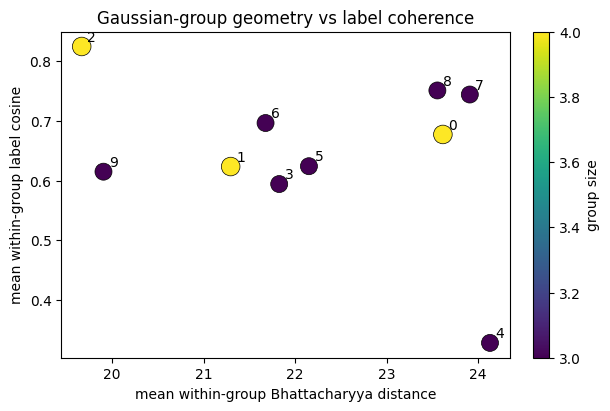

In [4]:
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
scatter = ax.scatter(
    groups["distance_mean"],
    groups["label_cosine_mean"],
    s=60 + 30 * groups["size"],
    c=groups["size"],
    cmap="viridis",
    edgecolor="black",
    linewidth=0.5,
)
for _, row in groups.iterrows():
    ax.annotate(str(int(row["group_id"])), (row["distance_mean"], row["label_cosine_mean"]), xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("mean within-group Bhattacharyya distance")
ax.set_ylabel("mean within-group label cosine")
ax.set_title("Gaussian-group geometry vs label coherence")
fig.colorbar(scatter, ax=ax, label="group size")
plt.show()

## Members and Labels

Use `show_group(group_id)` to inspect the labels and descriptions inside a Gaussian-group.

In [5]:
pd.set_option("display.max_colwidth", 220)

def show_group(group_id: int):
    cols = [
        "group_id",
        "group_size",
        "component_id",
        "label",
        "description",
        "mean_label_cosine",
        "mean_distance",
    ]
    return members.loc[members["group_id"] == group_id, cols].sort_values("component_id")

show_group(0)

,group_id,group_size,component_id,label,description,mean_label_cosine,mean_distance
0,0,4,103,grammatical function words,"The target tokens consist of high-frequency English stop words, including prepositions, conjunctions, articles, and pronouns, which serve to establish syntactic structure.",0.677141,23.615488
1,0,4,363,economic and monetary discourse,"Tokens related to currency, finance, and economic trends, specifically focusing on coinage, money issuance, and market factors.",0.677141,23.615488
2,0,4,415,grammatical function words,"The target tokens are high-frequency English stop words, including articles, conjunctions, prepositions, and pronouns, used to provide grammatical structure to the text.",0.677141,23.615488
3,0,4,899,grammatical function words,"The target tokens consist of high-frequency English stop words, including prepositions, conjunctions, articles, and punctuation, which serve to establish syntactic structure and relationships within sentences.",0.677141,23.615488


In [6]:
for group_id in groups["group_id"]:
    print(f"\n=== Gaussian-group {group_id} ===")
    display(show_group(int(group_id)))


=== Gaussian-group 0 ===


,group_id,group_size,component_id,label,description,mean_label_cosine,mean_distance
0,0,4,103,grammatical function words,"The target tokens consist of high-frequency English stop words, including prepositions, conjunctions, articles, and pronouns, which serve to establish syntactic structure.",0.677141,23.615488
1,0,4,363,economic and monetary discourse,"Tokens related to currency, finance, and economic trends, specifically focusing on coinage, money issuance, and market factors.",0.677141,23.615488
2,0,4,415,grammatical function words,"The target tokens are high-frequency English stop words, including articles, conjunctions, prepositions, and pronouns, used to provide grammatical structure to the text.",0.677141,23.615488
3,0,4,899,grammatical function words,"The target tokens consist of high-frequency English stop words, including prepositions, conjunctions, articles, and punctuation, which serve to establish syntactic structure and relationships within sentences.",0.677141,23.615488



=== Gaussian-group 1 ===


,group_id,group_size,component_id,label,description,mean_label_cosine,mean_distance
4,1,4,257,quantifiers and modifiers,"The target tokens function as quantifiers, intensifiers, or descriptive modifiers that specify amount, degree, or quality within a sentence.",0.623396,21.295959
5,1,4,292,plural nouns and collective entities,"The target tokens primarily consist of plural nouns representing groups of people, social organizations, or collective entities, often within the context of social movements or institutional structures.",0.623396,21.295959
6,1,4,395,common functional words and content terms,"A diverse set of high-frequency tokens including verbs, nouns, adverbs, and conjunctions that serve various grammatical and semantic roles within general discourse.",0.623396,21.295959
7,1,4,965,verbs of action and agency,"The target tokens are primarily verbs describing human actions, professional activities, efforts, or states of being in response to circumstances.",0.623396,21.295959



=== Gaussian-group 2 ===


...

,group_id,group_size,component_id,label,description,mean_label_cosine,mean_distance
24,7,3,63,Proper Noun Components,"The target tokens are frequently fragments of proper nouns, including usernames, software names, brand names, or specific technical identifiers found in code and forum discussions.",0.744045,23.909616
25,7,3,679,technical identifiers and code fragments,"The target tokens consist of programming identifiers, variable names, technical terms, and punctuation fragments commonly found in source code, configuration files, or technical documentation.",0.744045,23.909616
26,7,3,988,code_identifiers_and_syntax,"The target tokens represent programming language identifiers, such as class names, function names, file paths, and syntax symbols, or components of technical documentation and URLs.",0.744045,23.909616



=== Gaussian-group 8 ===


,group_id,group_size,component_id,label,description,mean_label_cosine,mean_distance
27,8,3,98,functional_and_technical_vocabulary,"The target tokens consist of a mix of high-frequency grammatical particles (prepositions, conjunctions, articles) and specific technical terminology related to software version control and cloud infrastructure.",0.750858,23.555298
28,8,3,711,functional_stop_words,"Common English grammatical particles, prepositions, conjunctions, and determiners used to provide syntactic structure to technical descriptions.",0.750858,23.555298
29,8,3,986,functional_connective_and_content_tokens,"A diverse set of high-frequency grammatical particles, pronouns, and content words used to establish logical flow, provide examples, or describe technical errors and processes.",0.750858,23.555298



=== Gaussian-group 9 ===


,group_id,group_size,component_id,label,description,mean_label_cosine,mean_distance
30,9,3,143,sociopolitical and ideological descriptors,"The target tokens consist of adjectives and nouns used to describe political ideologies, social identities, governance structures, and cultural frameworks.",0.614799,19.905823
31,9,3,742,discourse markers and functional words,"The target tokens consist of grammatical function words (prepositions, conjunctions, pronouns) and discourse markers used to structure logical relationships, transitions, and clauses within academic or formal prose.",0.614799,19.905823
32,9,3,884,grammatical function words and punctuation,"The target tokens consist primarily of high-frequency grammatical particles (prepositions, conjunctions, auxiliary verbs) and punctuation marks used to structure sentences.",0.614799,19.905823
